In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def f(x, y):
    ##Define the ODE and Euler Method
    
    return -2 * y * np.cos(x)

def euler_solve(h, x_end=10*np.pi, y0=1):
    x = np.arange(0, x_end + h, h)
    y = np.zeros_like(x)
    y[0] = y0

    for i in range(1, len(x)):
        y[i] = y[i-1] + h * f(x[i-1], y[i-1])

    return x, y

In [13]:
def y_exact(x):
    return np.exp(-2*np.sin(x))

##Exact solution (for error analysis)

In [15]:
#Step sizes
h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 1.0]

In [10]:
avg_y_values = []
avg_errors = []
local_errors = []
solutions = {}

for h in h_values:
    x, y = euler_solve(h)
    y_true = y_exact(x)

    solutions[h] = (x, y)

    # 1. Average of y-values for this run (required by assignment)
    avg_y = np.mean(y)
    avg_y_values.append(avg_y)

    # 2. Average absolute error vs exact solution
    avg_err = np.mean(np.abs(y - y_true))
    avg_errors.append(avg_err)

    # 3. Local error near x ≈ 15
    idx = np.argmin(np.abs(x - 15))
    local_err = abs(y[idx] - y_true[idx])
    local_errors.append(local_err)

# Plot 1 - Euler Solutions for All h

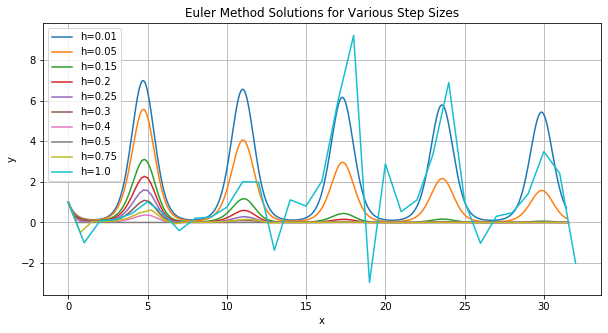

In [7]:
# Plot finally
plt.figure(figsize=(10,5))
for h in h_values:
    x, y = solutions[h]
    plt.plot(x, y, label=f"h={h}")

plt.title("Euler Method Solutions for Various Step Sizes")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2 - Average Error vs h

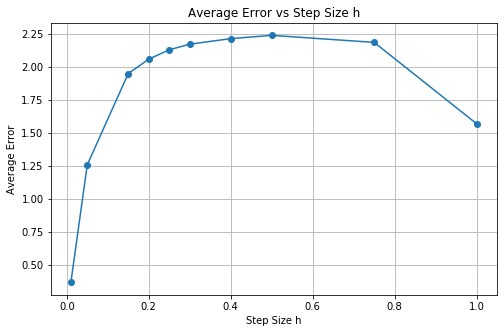

In [8]:
plt.figure(figsize=(8,5))
plt.plot(h_values, avg_errors, marker='o')
plt.title("Average Error vs Step Size h")
plt.xlabel("Step Size h")
plt.ylabel("Average Error")
plt.grid(True)
plt.show()

# Plot 3 - Local Error at x kinda = 15 vs h

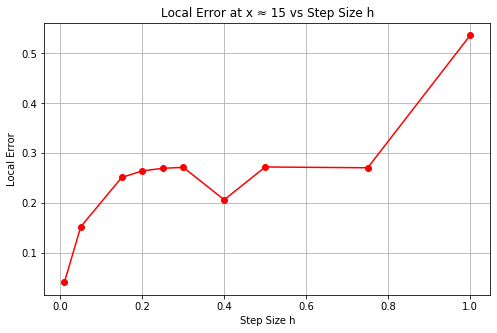

In [9]:
plt.figure(figsize=(8,5))
plt.plot(h_values, local_errors, marker='o', color='red')
plt.title("Local Error at x ≈ 15 vs Step Size h")
plt.xlabel("Step Size h")
plt.ylabel("Local Error")
plt.grid(True)
plt.show()

## Explanation

As the step size h increases, Euler’s method becomes noticeably less accurate because the method accumulates truncation error at every step. For small values of h, the numerical solution closely follows the true solution y(x)=e^{-2\sin (x)}, but as h grows, the approximation drifts and begins to distort the oscillatory behavior of the system. This leads to larger average errors across the interval and especially large local errors near x\approx 15, where accumulated phase and amplitude errors become more pronounced. Since Euler’s method is only first‑order accurate, the global error scales roughly linearly with h, which is why the error plots rise steadily as the step size increases. Overall, the results show that small step sizes produce stable, reliable solutions, while larger step sizes cause the method to lose accuracy and deviate significantly from the true behavior of the differential equation.
